# AI Waste Sorter

### Project Overview
In this project we try to build an AI model that can classify the kind of waste into 12 classes from images.

# Model Comparison

This Notebook will compare all the models that we have build so far, which is:
- CNN that we made from scratch including all models variant like simple, medium, and deep
- Transfer learning model that we implement already on the previous notebook like MobileNetV2 and EfficientNet-B0

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 6)

## Directory

In [2]:
BASE_DIR = Path.cwd()
MODELS_DIR = BASE_DIR / 'models'

print(f"Models directory: {MODELS_DIR}")
print(f"Directory exists: {MODELS_DIR.exists()}")

Models directory: /mnt/d/personal/AI and Machine Learning/waste sorter ai/models
Directory exists: True


## Load model

In [3]:
model_files = {
    'Simple CNN': 'simple_cnn_results.json',
    'Medium CNN': 'medium_cnn_results.json',
    'Deep CNN': 'deep_cnn_results.json',
    'MobileNetV2': 'mobilenetv2_results.json',
    'EfficientNetB0': 'efficientnetb0_results.json'
}

results = {}

for model_name, filename in model_files.items():
    filepath = MODELS_DIR / filename
    if filepath.exists():
        with open(filepath, 'r') as f:
            results[model_name] = json.load(f)
        print(f"{model_name}: loaded")
    else:
        print(f"{model_name}: not found")

print(f"\nTotal models loaded: {len(results)}")

Simple CNN: loaded
Medium CNN: loaded
Deep CNN: loaded
MobileNetV2: loaded
EfficientNetB0: loaded

Total models loaded: 5


## Model results comparison

In [4]:
if results:
    models_data = []
    
    for model_name, data in results.items():
        model_type = data.get('model_type', 'CNN from Scratch')
        
        models_data.append({
            'Model': model_name,
            'Type': model_type,
            'Parameters': data['parameters'],
            'Test Accuracy': data['test_accuracy'],
            'Best Val Accuracy': data['best_val_accuracy'],
            'Final Train Accuracy': data['final_train_accuracy'],
            'Epochs Trained': data['epochs_trained']
        })
    
    comparison_df = pd.DataFrame(models_data)
    comparison_df['Parameters (M)'] = comparison_df['Parameters'] / 1e6
    
    comparison_df = comparison_df.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
    
    print("\nModel Comparison (sorted by Test Accuracy):")
    print(comparison_df.to_string(index=False))
    
    best_model_idx = 0
    best_model_name = comparison_df.loc[best_model_idx, 'Model']
    best_accuracy = comparison_df.loc[best_model_idx, 'Test Accuracy']
    best_params = comparison_df.loc[best_model_idx, 'Parameters (M)']
    
    print(f"\nBest Model: {best_model_name}")
    print(f"Test Accuracy: {best_accuracy:.4f}")
    print(f"Parameters: {best_params:.2f}M")
else:
    print("\nNo model results found")


Model Comparison (sorted by Test Accuracy):
         Model              Type  Parameters  Test Accuracy  Best Val Accuracy  Final Train Accuracy  Epochs Trained  Parameters (M)
   MobileNetV2 Transfer Learning     2621900       0.970437           0.965161              0.994896              70        2.621900
    Medium CNN  CNN from Scratch    26412204       0.852185           0.863871              0.831078             100       26.412204
      Deep CNN  CNN from Scratch    28584620       0.836118           0.843871              0.812441             100       28.584620
    Simple CNN  CNN from Scratch    25788620       0.803342           0.815484              0.799739             100       25.788620
EfficientNetB0 Transfer Learning     4413487       0.455656           0.443871              0.554131              70        4.413487

Best Model: MobileNetV2
Test Accuracy: 0.9704
Parameters: 2.62M


## Comparison plot

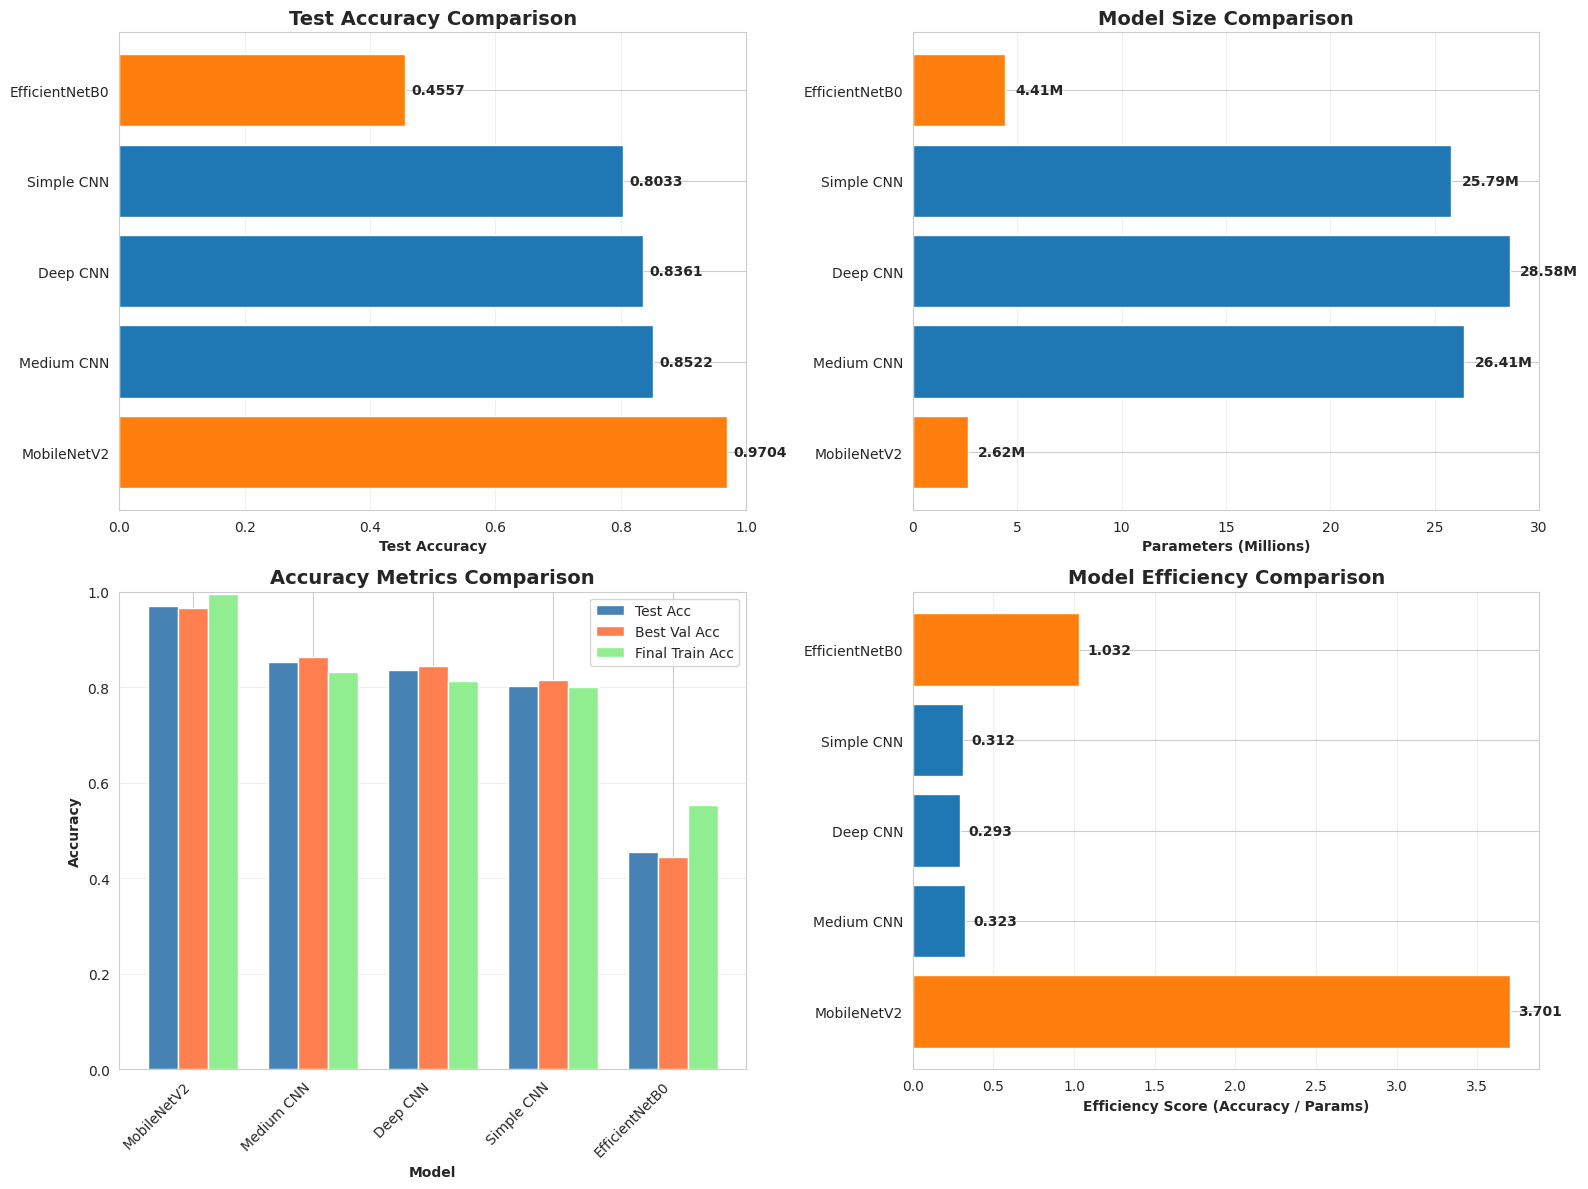

In [5]:
if results:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    colors = ['#1f77b4' if t == 'CNN from Scratch' else '#ff7f0e' for t in comparison_df['Type']]
    
    axes[0, 0].barh(comparison_df['Model'], comparison_df['Test Accuracy'], color=colors)
    axes[0, 0].set_xlabel('Test Accuracy', fontweight='bold')
    axes[0, 0].set_title('Test Accuracy Comparison', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlim([0, 1])
    axes[0, 0].grid(axis='x', alpha=0.3)
    
    for i, v in enumerate(comparison_df['Test Accuracy']):
        axes[0, 0].text(v + 0.01, i, f'{v:.4f}', va='center', fontweight='bold')
    
    axes[0, 1].barh(comparison_df['Model'], comparison_df['Parameters (M)'], color=colors)
    axes[0, 1].set_xlabel('Parameters (Millions)', fontweight='bold')
    axes[0, 1].set_title('Model Size Comparison', fontsize=14, fontweight='bold')
    axes[0, 1].grid(axis='x', alpha=0.3)
    
    for i, v in enumerate(comparison_df['Parameters (M)']):
        axes[0, 1].text(v + 0.5, i, f'{v:.2f}M', va='center', fontweight='bold')
    
    x = np.arange(len(comparison_df))
    width = 0.25
    
    axes[1, 0].bar(x - width, comparison_df['Test Accuracy'], width, label='Test Acc', color='steelblue')
    axes[1, 0].bar(x, comparison_df['Best Val Accuracy'], width, label='Best Val Acc', color='coral')
    axes[1, 0].bar(x + width, comparison_df['Final Train Accuracy'], width, label='Final Train Acc', color='lightgreen')
    
    axes[1, 0].set_xlabel('Model', fontweight='bold')
    axes[1, 0].set_ylabel('Accuracy', fontweight='bold')
    axes[1, 0].set_title('Accuracy Metrics Comparison', fontsize=14, fontweight='bold')
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
    axes[1, 0].legend()
    axes[1, 0].grid(axis='y', alpha=0.3)
    axes[1, 0].set_ylim([0, 1])
    
    efficiency = comparison_df['Test Accuracy'] / (comparison_df['Parameters (M)'] / 10)
    axes[1, 1].barh(comparison_df['Model'], efficiency, color=colors)
    axes[1, 1].set_xlabel('Efficiency Score (Accuracy / Params)', fontweight='bold')
    axes[1, 1].set_title('Model Efficiency Comparison', fontsize=14, fontweight='bold')
    axes[1, 1].grid(axis='x', alpha=0.3)
    
    for i, v in enumerate(efficiency):
        axes[1, 1].text(v + 0.05, i, f'{v:.3f}', va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(MODELS_DIR / 'final_models_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

## Aize and accuracy trade off

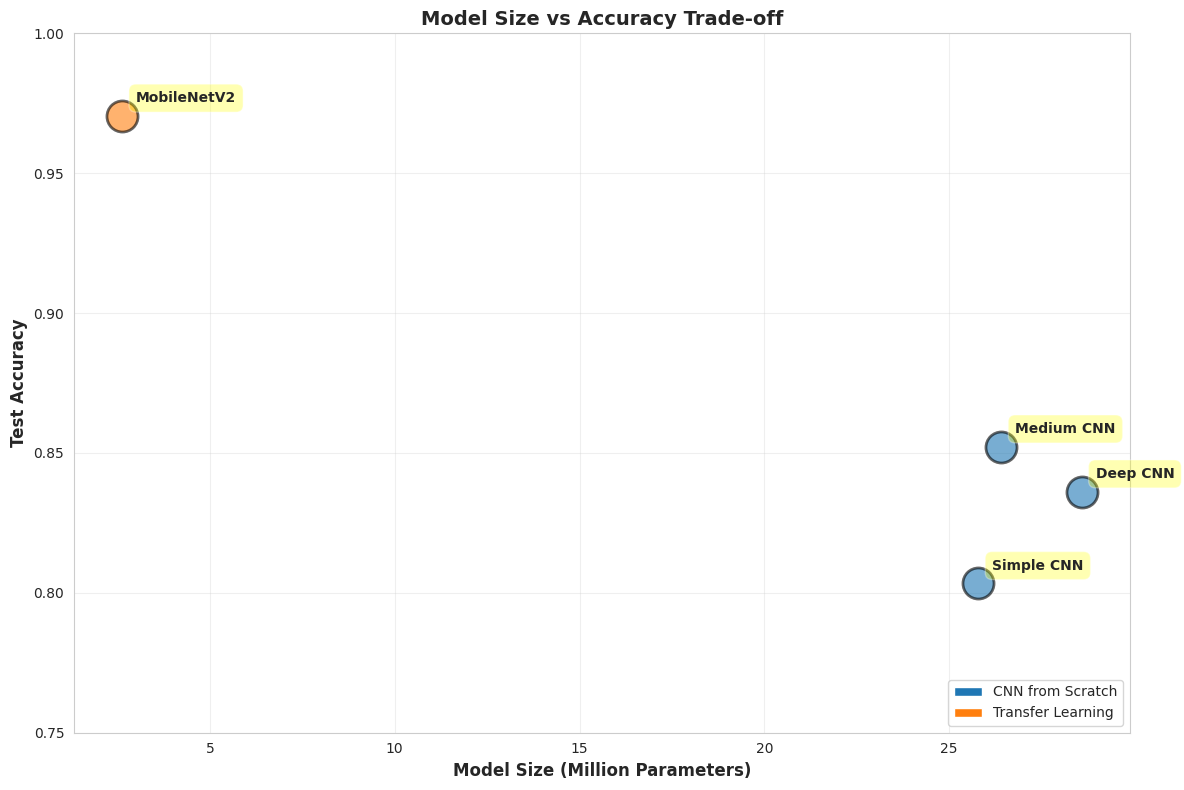

In [6]:
if results:
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    
    scatter_colors = ['#1f77b4' if t == 'CNN from Scratch' else '#ff7f0e' for t in comparison_df['Type']]
    
    for idx, row in comparison_df.iterrows():
        ax.scatter(row['Parameters (M)'], row['Test Accuracy'], 
                  s=500, alpha=0.6, c=[scatter_colors[idx]], edgecolors='black', linewidth=2)
        ax.annotate(row['Model'], 
                   (row['Parameters (M)'], row['Test Accuracy']),
                   xytext=(10, 10), textcoords='offset points',
                   fontsize=10, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.3))
    
    ax.set_xlabel('Model Size (Million Parameters)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Test Accuracy', fontsize=12, fontweight='bold')
    ax.set_title('Model Size vs Accuracy Trade-off', fontsize=14, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.set_ylim([0.75, 1.0])
    
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#1f77b4', label='CNN from Scratch'),
        Patch(facecolor='#ff7f0e', label='Transfer Learning')
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(MODELS_DIR / 'size_vs_accuracy_tradeoff.png', dpi=300, bbox_inches='tight')
    plt.show()

## CNN from scratch and transfer learning comparison summary

In [7]:
if results:
    cnn_models = comparison_df[comparison_df['Type'] == 'CNN from Scratch']
    transfer_models = comparison_df[comparison_df['Type'] == 'Transfer Learning']
    
    print("\nCNN from Scratch Summary:")
    if len(cnn_models) > 0:
        print(f"Average Test Accuracy: {cnn_models['Test Accuracy'].mean():.4f}")
        print(f"Average Parameters: {cnn_models['Parameters (M)'].mean():.2f}M")
        print(f"Best CNN: {cnn_models.iloc[0]['Model']} ({cnn_models.iloc[0]['Test Accuracy']:.4f})")
    
    print("\nTransfer Learning Summary:")
    if len(transfer_models) > 0:
        print(f"Average Test Accuracy: {transfer_models['Test Accuracy'].mean():.4f}")
        print(f"Average Parameters: {transfer_models['Parameters (M)'].mean():.2f}M")
        print(f"Best Transfer: {transfer_models.iloc[0]['Model']} ({transfer_models.iloc[0]['Test Accuracy']:.4f})")
    
    if len(cnn_models) > 0 and len(transfer_models) > 0:
        improvement = transfer_models['Test Accuracy'].max() - cnn_models['Test Accuracy'].max()
        size_reduction = ((cnn_models['Parameters (M)'].mean() - transfer_models['Parameters (M)'].mean()) / 
                         cnn_models['Parameters (M)'].mean() * 100)
        print(f"\nTransfer Learning Benefits:")
        print(f"Accuracy improvement: +{improvement:.4f} ({improvement*100:.2f}%)")
        print(f"Model size reduction: {size_reduction:.1f}%")


CNN from Scratch Summary:
Average Test Accuracy: 0.8305
Average Parameters: 26.93M
Best CNN: Medium CNN (0.8522)

Transfer Learning Summary:
Average Test Accuracy: 0.7130
Average Parameters: 3.52M
Best Transfer: MobileNetV2 (0.9704)

Transfer Learning Benefits:
Accuracy improvement: +0.1183 (11.83%)
Model size reduction: 86.9%


## Save comparison

In [8]:
if results:
    comparison_df.to_csv(MODELS_DIR / 'final_models_comparison.csv', index=False)
    
    final_summary = {
        'best_overall_model': {
            'name': best_model_name,
            'test_accuracy': float(best_accuracy),
            'parameters': int(comparison_df.loc[best_model_idx, 'Parameters']),
            'type': comparison_df.loc[best_model_idx, 'Type']
        },
        'all_models': models_data,
        'summary_statistics': {
            'total_models_trained': len(results),
            'cnn_models': len(cnn_models) if len(cnn_models) > 0 else 0,
            'transfer_models': len(transfer_models) if len(transfer_models) > 0 else 0,
            'best_accuracy': float(comparison_df['Test Accuracy'].max()),
            'average_accuracy': float(comparison_df['Test Accuracy'].mean()),
            'smallest_model': comparison_df.loc[comparison_df['Parameters (M)'].idxmin(), 'Model'],
            'largest_model': comparison_df.loc[comparison_df['Parameters (M)'].idxmax(), 'Model']
        }
    }
    
    with open(MODELS_DIR / 'final_training_summary.json', 'w') as f:
        json.dump(final_summary, f, indent=2)

## Overall summary

In [11]:
if results:
    print("SUMMARY")
    print(f"\nTotal models trained: {len(results)}")
    print(f"\nBest Overall Model: {best_model_name}")
    print(f"Test Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
    print(f"Model Size: {best_params:.2f}M parameters")
    print(f"Model Type: {comparison_df.loc[best_model_idx, 'Type']}")
    
    print("\nTop 3 Models by Accuracy:")
    for i in range(min(3, len(comparison_df))):
        model = comparison_df.iloc[i]
        print(f"{i+1}. {model['Model']:20} - {model['Test Accuracy']:.4f} ({model['Parameters (M)']:.2f}M params)")
    
else:
    print("No models")

SUMMARY

Total models trained: 5

Best Overall Model: MobileNetV2
Test Accuracy: 0.9704 (97.04%)
Model Size: 2.62M parameters
Model Type: Transfer Learning

Top 3 Models by Accuracy:
1. MobileNetV2          - 0.9704 (2.62M params)
2. Medium CNN           - 0.8522 (26.41M params)
3. Deep CNN             - 0.8361 (28.58M params)
